# End-to-End Machine Learning: Machine Downtime Prediction (Predictive Maintenance)

This project predicts whether a CNC machine reading indicates an upcoming **Machine Failure** or **No Machine Failure**, using live sensor data (pressure, temperature, vibration, speed, voltage, torque, and cutting force).

The notebook covers the complete workflow: local data loading, cleaning, EDA, validation-based model selection, training, evaluation,saving, and a simple interactive demo.

## Step 1- Set Up the Environment

If the libraries are missing, uncomment and run the next line once. Restart the kernel after installation.

In [38]:
# Run this line only if the libraries are not installed:
# %pip install pandas scikit-learn matplotlib seaborn joblib gradio

### Import Libraries and Create Project Folders

We use a fixed random seed so the split and model results can be reproduced.

In [39]:
from pathlib import Path
from time import perf_counter
from datetime import datetime, timezone
import json
import platform
import sys

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn

from sklearn.compose import ColumnTransformer
from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.svm import LinearSVC

print("libraries imported successfully")

libraries imported successfully


In [40]:
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_theme(style="whitegrid")

PROJECT_DIR = Path.cwd()
MODEL_DIR = PROJECT_DIR / "Model"

MODEL_DIR.mkdir(parents=True, exist_ok=True)

print("Project directory:", PROJECT_DIR)
print("Model directory:", MODEL_DIR)

Project directory: /content
Model directory: /content/Model


## Step 2- Load the Machine Downtime Dataset from a URL


In [41]:
DATA_URL = (
   "https://raw.githubusercontent.com/mohamedalaaeldin-momo/Predictive-maintenance-system-for-industrial-equipment-Final-Project-/refs/heads/main/Machine%20Downtime.csv"
)


In [42]:
raw_df = pd.read_csv(DATA_URL)

print("Dataset loaded successfully")

Dataset loaded successfully


### Check Dataset Size and Columns

In [43]:
number_of_rows = raw_df.shape[0]
number_of_columns = raw_df.shape[1]

print("Number of rows:", number_of_rows)
print("Number of columns:", number_of_columns)
print("Column names:", raw_df.columns.to_list())

Number of rows: 2500
Number of columns: 16
Column names: ['Date', 'Machine_ID', 'Assembly_Line_No', 'Hydraulic_Pressure(bar)', 'Coolant_Pressure(bar)', 'Air_System_Pressure(bar)', 'Coolant_Temperature', 'Hydraulic_Oil_Temperature(?C)', 'Spindle_Bearing_Temperature(?C)', 'Spindle_Vibration(?m)', 'Tool_Vibration(?m)', 'Spindle_Speed(RPM)', 'Voltage(volts)', 'Torque(Nm)', 'Cutting(kN)', 'Downtime']


### Preview the First Rows

In [44]:
print(raw_df.head(10).round(3))

         Date            Machine_ID Assembly_Line_No  Hydraulic_Pressure(bar)  \
0  31-12-2021  Makino-L1-Unit1-2013     Shopfloor-L1                   71.040   
1  31-12-2021  Makino-L1-Unit1-2013     Shopfloor-L1                  125.330   
2  31-12-2021  Makino-L3-Unit1-2015     Shopfloor-L3                   71.120   
3  31-05-2022  Makino-L2-Unit1-2015     Shopfloor-L2                  139.340   
4  31-03-2022  Makino-L1-Unit1-2013     Shopfloor-L1                   60.510   
5  31-03-2022  Makino-L2-Unit1-2015     Shopfloor-L2                  137.370   
6  31-03-2022  Makino-L1-Unit1-2013     Shopfloor-L1                  135.930   
7  31-03-2022  Makino-L3-Unit1-2015     Shopfloor-L3                  127.715   
8  31-03-2022  Makino-L3-Unit1-2015     Shopfloor-L3                  123.618   
9  31-03-2022  Makino-L3-Unit1-2015     Shopfloor-L3                  134.020   

   Coolant_Pressure(bar)  Air_System_Pressure(bar)  Coolant_Temperature  \
0                  6.934         

### Inspect Column Types

In [45]:
raw_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 16 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Date                             2500 non-null   object 
 1   Machine_ID                       2500 non-null   object 
 2   Assembly_Line_No                 2500 non-null   object 
 3   Hydraulic_Pressure(bar)          2490 non-null   float64
 4   Coolant_Pressure(bar)            2481 non-null   float64
 5   Air_System_Pressure(bar)         2483 non-null   float64
 6   Coolant_Temperature              2488 non-null   float64
 7   Hydraulic_Oil_Temperature(?C)    2484 non-null   float64
 8   Spindle_Bearing_Temperature(?C)  2493 non-null   float64
 9   Spindle_Vibration(?m)            2489 non-null   float64
 10  Tool_Vibration(?m)               2489 non-null   float64
 11  Spindle_Speed(RPM)               2494 non-null   float64
 12  Voltage(volts)      

### Count Missing Values

In [46]:
missing_values = raw_df.isnull().sum()

print(missing_values)

Date                                0
Machine_ID                          0
Assembly_Line_No                    0
Hydraulic_Pressure(bar)            10
Coolant_Pressure(bar)              19
Air_System_Pressure(bar)           17
Coolant_Temperature                12
Hydraulic_Oil_Temperature(?C)      16
Spindle_Bearing_Temperature(?C)     7
Spindle_Vibration(?m)              11
Tool_Vibration(?m)                 11
Spindle_Speed(RPM)                  6
Voltage(volts)                      6
Torque(Nm)                         21
Cutting(kN)                         7
Downtime                            0
dtype: int64


### Count Duplicate Rows

In [47]:
duplicate_rows = raw_df.duplicated().sum()

print("Number of duplicate rows:", duplicate_rows)

Number of duplicate rows: 0


### Inspect the Downtime Distribution

In [48]:
downtime_counts = raw_df[
    "Downtime"
].value_counts(dropna=False)

print(downtime_counts)

Downtime
Machine_Failure       1265
No_Machine_Failure    1235
Name: count, dtype: int64


### Plot the Downtime Distribution

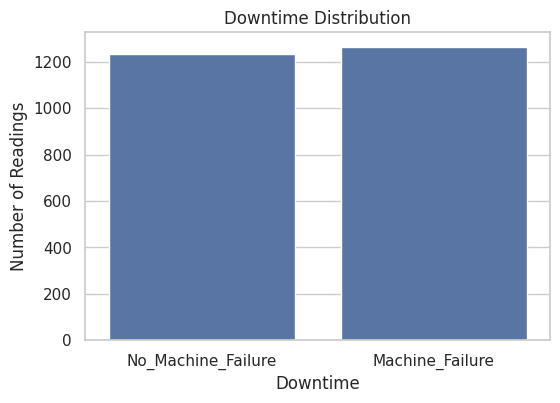

In [49]:
plt.figure(figsize=(6, 4))

sns.countplot(
    data=raw_df,
    x="Downtime",
    order=[
        "No_Machine_Failure",
        "Machine_Failure",
    ],
    color="#4C72B0",
)

plt.title("Downtime Distribution")
plt.xlabel("Downtime")
plt.ylabel("Number of Readings")
plt.show()

## Step 4: Clean the Data



In [50]:
SENSOR_COLUMNS = [
    "Hydraulic_Pressure(bar)",
    "Coolant_Pressure(bar)",
    "Air_System_Pressure(bar)",
    "Coolant_Temperature",
    "Hydraulic_Oil_Temperature(?C)",
    "Spindle_Bearing_Temperature(?C)",
    "Spindle_Vibration(?m)",
    "Tool_Vibration(?m)",
    "Spindle_Speed(RPM)",
    "Voltage(volts)",
    "Torque(Nm)",
    "Cutting(kN)",
]

CATEGORICAL_COLUMNS = ["Machine_ID"]

FEATURE_COLUMNS = SENSOR_COLUMNS + CATEGORICAL_COLUMNS


clean_df = (
    raw_df[["Date"] + FEATURE_COLUMNS + ["Downtime"]]
    .drop_duplicates()
    .copy()
)


clean_df[SENSOR_COLUMNS] = clean_df[SENSOR_COLUMNS].fillna(
    clean_df[SENSOR_COLUMNS].median()
)

clean_df["label"] = (
    clean_df["Downtime"] == "Machine_Failure"
).astype(int)

print("Rows before cleaning:", len(raw_df))
print("Rows after cleaning:", len(clean_df))

Rows before cleaning: 2500
Rows after cleaning: 2500


## Step 5: Split Data and train model to rank & Select the Top 6 Most Influential Features




In [51]:
X_train, X_test, y_train, y_test = train_test_split(
    clean_df[FEATURE_COLUMNS],
    clean_df["label"],
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=clean_df["label"],
)

split_summary = pd.DataFrame({
    "rows": [
        len(X_train),
        len(X_test),
    ],
    "failure_ratio": [
        y_train.mean(),
        y_test.mean(),
    ],
}, index=["train", "test"])

print(split_summary.round(3))

       rows  failure_ratio
train  2000          0.506
test    500          0.506


pipeline for feature selection model **(randomforest)** for ranking


In [52]:
screening_preprocessor = ColumnTransformer(
    transformers=[
        (
            "sensors",
            Pipeline([
                ("impute", SimpleImputer(strategy="median")),
                ("scale", StandardScaler()),
            ]),
            SENSOR_COLUMNS,
        ),
        (
            "machine_id",
            OneHotEncoder(handle_unknown="ignore"),
            CATEGORICAL_COLUMNS,
        ),
    ]
)

screening_model = Pipeline([
    ("preprocess", screening_preprocessor),
    (
        "classifier",
        RandomForestClassifier(
            n_estimators=300,
            random_state=RANDOM_STATE,
            n_jobs=-1,
        ),
    ),
])

screening_model.fit(X_train, y_train)

screening_feature_names = (
    screening_model.named_steps["preprocess"].get_feature_names_out()
)
screening_importances = (
    screening_model.named_steps["classifier"].feature_importances_
)


def original_column_name(encoded_name):
    if encoded_name.startswith("sensors__"):
        return encoded_name[len("sensors__"):]
    if encoded_name.startswith("machine_id__Machine_ID_"):
        return "Machine_ID"
    return encoded_name


aggregated_importance = (
    pd.Series(screening_importances, index=screening_feature_names)
    .groupby(original_column_name)
    .sum()
    .sort_values(ascending=False)
)

print(aggregated_importance.round(4))

Hydraulic_Pressure(bar)            0.2304
Torque(Nm)                         0.2292
Cutting(kN)                        0.2035
Coolant_Pressure(bar)              0.1546
Spindle_Speed(RPM)                 0.0793
Coolant_Temperature                0.0351
Spindle_Bearing_Temperature(?C)    0.0118
Spindle_Vibration(?m)              0.0113
Hydraulic_Oil_Temperature(?C)      0.0108
Air_System_Pressure(bar)           0.0107
Tool_Vibration(?m)                 0.0106
Voltage(volts)                     0.0085
Machine_ID                         0.0040
dtype: float64


select the top 6 features

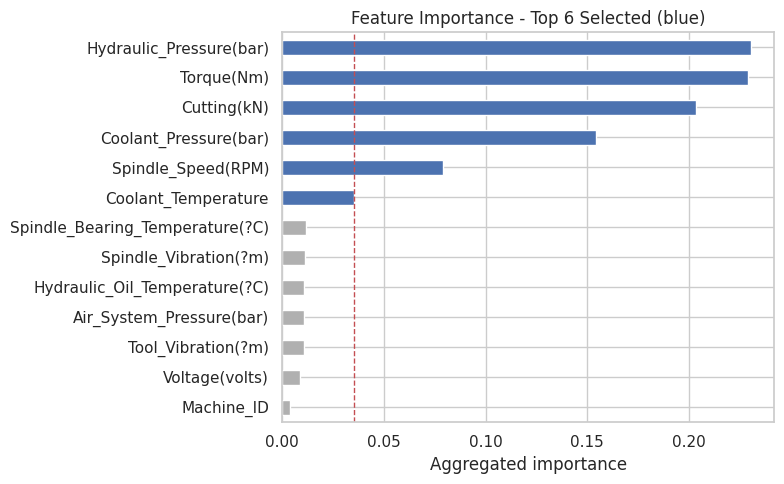

In [53]:
TOP_K = 6

top_features = aggregated_importance.head(TOP_K).index.tolist()

plt.figure(figsize=(8, 5))

bar_colors = [
    "#4C72B0" if name in top_features else "#B0B0B0"
    for name in aggregated_importance.index
]

aggregated_importance.sort_values().plot.barh(color=list(reversed(bar_colors)))
plt.axvline(
    aggregated_importance.iloc[TOP_K - 1],
    color="#C44E52",
    linestyle="--",
    linewidth=1,
)
plt.title(f"Feature Importance - Top {TOP_K} Selected (blue)")
plt.xlabel("Aggregated importance")
plt.tight_layout()
plt.show()

In [54]:
SENSOR_COLUMNS = [c for c in top_features if c != "Machine_ID"]
CATEGORICAL_COLUMNS = [c for c in top_features if c == "Machine_ID"]
FEATURE_COLUMNS = SENSOR_COLUMNS + CATEGORICAL_COLUMNS

X_train = X_train[FEATURE_COLUMNS]
X_test = X_test[FEATURE_COLUMNS]

print(f"Selected top {TOP_K} features:")
for rank, feature_name in enumerate(FEATURE_COLUMNS, start=1):
    print(f"  {rank}. {feature_name}")

Selected top 6 features:
  1. Hydraulic_Pressure(bar)
  2. Torque(Nm)
  3. Cutting(kN)
  4. Coolant_Pressure(bar)
  5. Spindle_Speed(RPM)
  6. Coolant_Temperature


## Step 6: Explore the Training Data


In [79]:
training_eda = X_train.copy()
training_eda["label"] = y_train.reset_index(drop=True) if False else y_train.values
training_eda["downtime"] = training_eda["label"].map({
    0: "No_Machine_Failure",
    1: "Machine_Failure",
})

print(training_eda[SENSOR_COLUMNS].describe().round(2).to_string())

       Hydraulic_Pressure(bar)  Torque(Nm)  Cutting(kN)  Coolant_Pressure(bar)  Spindle_Speed(RPM)  Coolant_Temperature
count                  2000.00     2000.00      2000.00                2000.00             2000.00              2000.00
mean                    101.45       25.28         2.79                   4.95            20318.07                18.49
std                      30.52        6.08         0.62                   1.00             3818.20                 8.58
min                     -14.33        0.00         1.85                   0.32                0.00                 4.10
25%                      76.31       21.84         2.26                   4.47            17919.00                10.28
50%                      96.76       24.65         2.78                   4.94            20131.00                21.10
75%                     126.85       30.51         3.28                   5.52            22592.50                25.60
max                     191.00       55.

### Compare Sensor Readings by Downtime Status


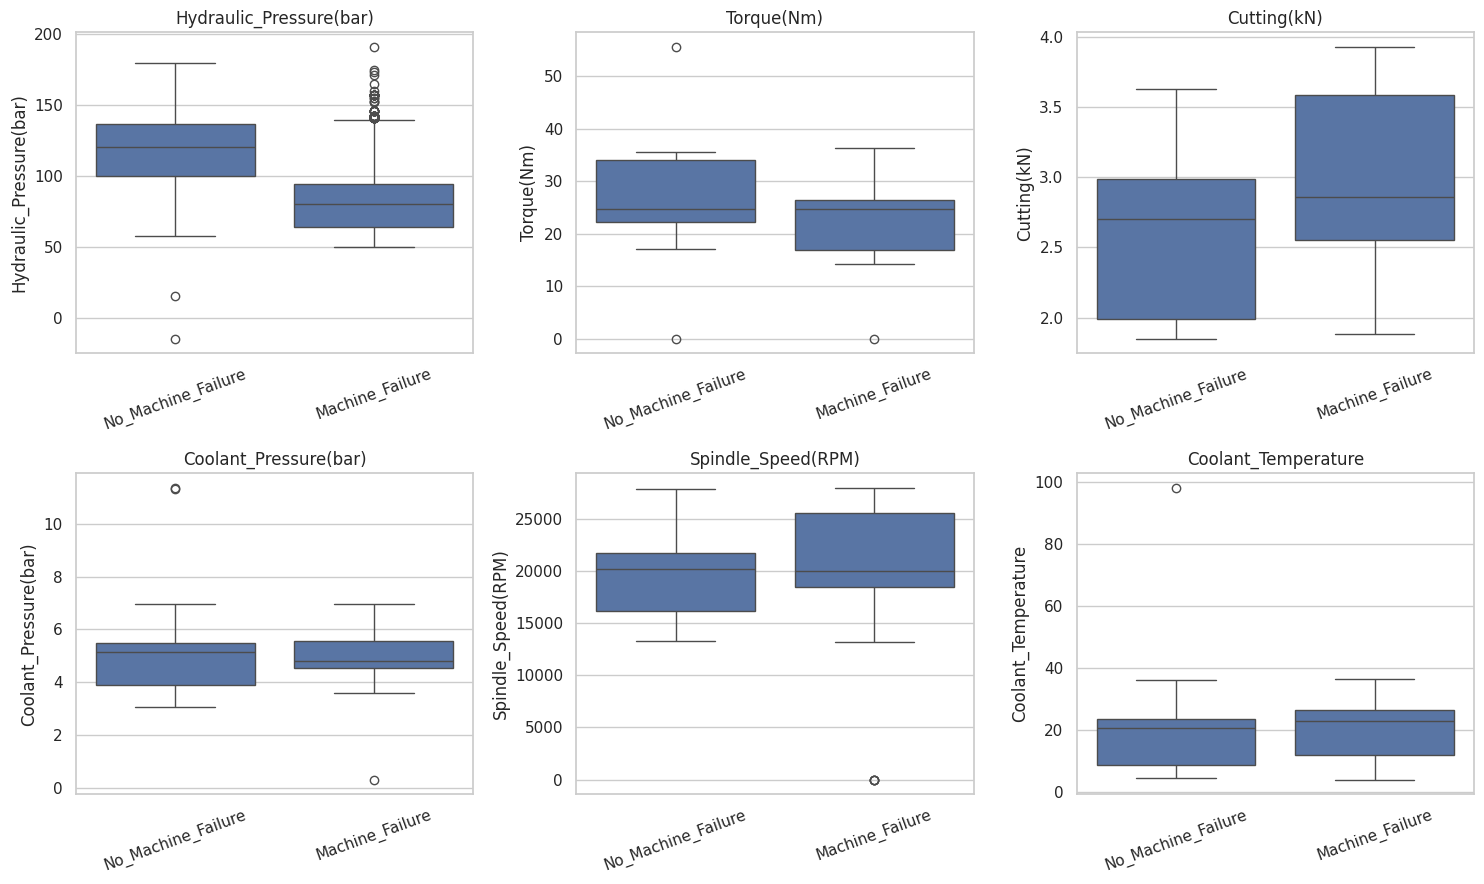

In [56]:
import math

n_sensors = len(SENSOR_COLUMNS)
n_cols = 3
n_rows = math.ceil(n_sensors / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4.5 * n_rows))
axes = axes.flatten()

for ax, sensor in zip(axes, SENSOR_COLUMNS):
    sns.boxplot(
        data=training_eda,
        x="downtime",
        y=sensor,
        order=["No_Machine_Failure", "Machine_Failure"],
        color="#4C72B0",
        ax=ax,
    )
    ax.set_title(sensor)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=20)

for ax in axes[n_sensors:]:
    ax.axis("off")

plt.tight_layout()
plt.show()

### Sensor Correlation Heatmap

This helps spot redundant sensors among the selected features.

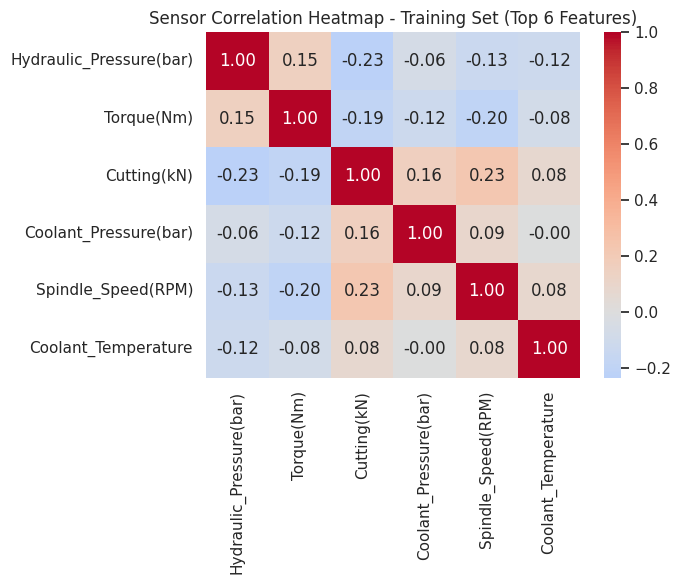

In [57]:
plt.figure(figsize=(7, 6))

sns.heatmap(
    training_eda[SENSOR_COLUMNS].corr(),
    cmap="coolwarm",
    center=0,
    annot=True,
    fmt=".2f",
)

plt.title("Sensor Correlation Heatmap - Training Set (Top 6 Features)")
plt.tight_layout()
plt.show()

## Step 7: Build Preprocessing and Candidate Models

All three candidate models share the **same preprocessing**:

- Missing sensor values are imputed with the **median**
- Sensor readings are **scaled**.

In [58]:
preprocessing_steps = [
    (
        "sensors",
        Pipeline([
            ("impute", SimpleImputer(strategy="median")),
            ("scale", StandardScaler()),
        ]),
        SENSOR_COLUMNS,
    ),
]

if CATEGORICAL_COLUMNS:
    preprocessing_steps.append((
        "machine_id",
        OneHotEncoder(handle_unknown="ignore"),
        CATEGORICAL_COLUMNS,
    ))

preprocessor = ColumnTransformer(transformers=preprocessing_steps)

### Create Validation Data

In [78]:
X_model_train, X_validation, y_model_train, y_validation = (
    train_test_split(
        X_train,
        y_train,
        test_size=0.20,
        random_state=RANDOM_STATE,
        stratify=y_train,
    )
)

validation_split_summary = pd.DataFrame({
    "rows": [
        len(X_model_train),
        len(X_validation),
    ],
    "failure_ratio": [
        y_model_train.mean(),
        y_validation.mean(),
    ],
}, index=["model_train", "validation"])

print(validation_split_summary.round(3))

             rows  failure_ratio
model_train  1600          0.506
validation    400          0.505


### Build the Logistic Regression Pipeline

In [60]:
logistic_model = Pipeline([
    ("preprocess", preprocessor),
    (
        "classifier",
        LogisticRegression(
            max_iter=1000,
            random_state=RANDOM_STATE,
        ),
    ),
])

### Build the Linear SVM Pipeline

In [61]:
svm_model = Pipeline([
    ("preprocess", preprocessor),
    (
        "classifier",
        CalibratedClassifierCV(
            estimator=LinearSVC(
                random_state=RANDOM_STATE,
                max_iter=5000,
            ),
            cv=3,
        ),
    ),
])

### Build the Random Forest Pipeline

In [62]:
random_forest_model = Pipeline([
    ("preprocess", preprocessor),
    (
        "classifier",
        RandomForestClassifier(
            n_estimators=300,
            random_state=RANDOM_STATE,
            n_jobs=-1,
        ),
    ),
])

## Step 8: Train, Validate, Compare, and Test Models

In [63]:
def evaluate(model_name, fitted_model, X_eval, y_eval):
    predictions = fitted_model.predict(X_eval)
    probabilities = fitted_model.predict_proba(X_eval)[:, 1]
    return {
        "model": model_name,
        "accuracy": accuracy_score(y_eval, predictions),
        "precision": precision_score(y_eval, predictions),
        "recall": recall_score(y_eval, predictions),
        "f1": f1_score(y_eval, predictions),
        "roc_auc": roc_auc_score(y_eval, probabilities),
    }

## Train and Validate Linear logistic regression

In [64]:
logistic_start = perf_counter()

logistic_model.fit(
    X_model_train,
    y_model_train,
)


logistic_validation_metrics = evaluate(
    "Logistic Regression",
    logistic_model,
    X_validation,
    y_validation,
)


print(logistic_validation_metrics)

{'model': 'Logistic Regression', 'accuracy': 0.86, 'precision': 0.8762886597938144, 'recall': 0.8415841584158416, 'f1': 0.8585858585858586, 'roc_auc': np.float64(0.9278677867786779)}


### Train and Validate Linear SVM

In [65]:
svm_start = perf_counter()

svm_model.fit(
    X_model_train,
    y_model_train,
)



svm_validation_metrics = evaluate(
    "Linear SVM",
    svm_model,
    X_validation,
    y_validation,
)


print(svm_validation_metrics)

{'model': 'Linear SVM', 'accuracy': 0.8575, 'precision': 0.8756476683937824, 'recall': 0.8366336633663366, 'f1': 0.8556962025316456, 'roc_auc': np.float64(0.928017801780178)}


### Train and Validate Random Forest

In [66]:
random_forest_start = perf_counter()

random_forest_model.fit(
    X_model_train,
    y_model_train,
)


random_forest_validation_metrics = evaluate(
    "Random Forest",
    random_forest_model,
    X_validation,
    y_validation,
)


print(random_forest_validation_metrics)

{'model': 'Random Forest', 'accuracy': 0.985, 'precision': 0.99, 'recall': 0.9801980198019802, 'f1': 0.9850746268656716, 'roc_auc': np.float64(0.9992249224922491)}


### Compare the Models and Select the Best

In [67]:
validation_results = pd.DataFrame([
    logistic_validation_metrics,
    svm_validation_metrics,
    random_forest_validation_metrics,
])

validation_results = (
    validation_results
    .set_index("model")
    .sort_values(by="f1", ascending=False)
)

print(validation_results.round(4).to_string())

best_model_name = validation_results["f1"].idxmax()

candidate_models = {
    "Logistic Regression": logistic_model,
    "Linear SVM": svm_model,
    "Random Forest": random_forest_model,
}

model = candidate_models[best_model_name]

print()
print("Selected model:", best_model_name)

                     accuracy  precision  recall      f1  roc_auc
model                                                            
Random Forest          0.9850     0.9900  0.9802  0.9851   0.9992
Logistic Regression    0.8600     0.8763  0.8416  0.8586   0.9279
Linear SVM             0.8575     0.8756  0.8366  0.8557   0.9280

Selected model: Random Forest


### Retrain the Selected Model and Evaluate on Test

The selected model is retrained on the full training set (validation rows included) before the final, one-time test evaluation.

In [85]:
training_start = perf_counter()

model.fit(
    X_train,
    y_train,
)



test_predictions = model.predict(X_test)
test_probabilities = model.predict_proba(X_test)

classifier_classes = (
    model.named_steps["classifier"].classes_
)


positive_probabilities = test_probabilities[:, 1]

test_metrics = {
    "accuracy": accuracy_score(y_test, test_predictions),
    "precision": precision_score(y_test, test_predictions),
    "recall": recall_score(y_test, test_predictions),
    "f1": f1_score(y_test, test_predictions),
    "roc_auc": roc_auc_score(y_test, positive_probabilities),
}

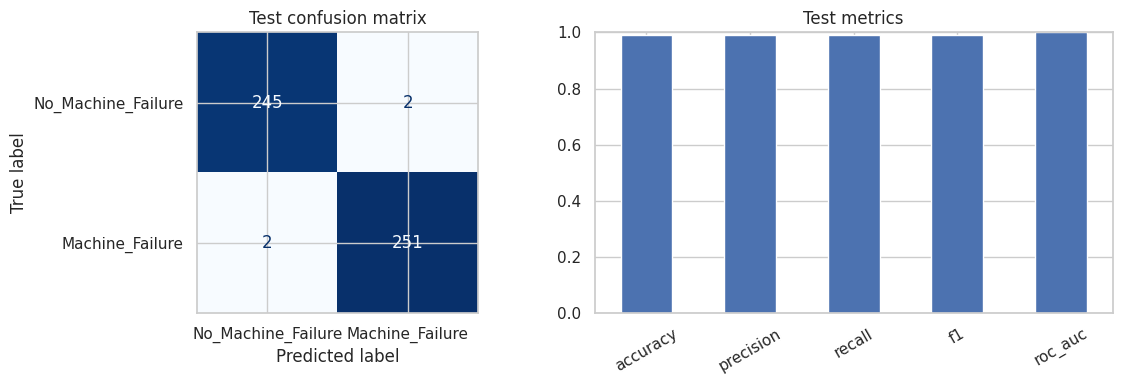

In [69]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    test_predictions,
    labels=[0, 1],
    display_labels=["No_Machine_Failure", "Machine_Failure"],
    cmap="Blues",
    colorbar=False,
    ax=axes[0],
)
axes[0].set_title("Test confusion matrix")

metric_names = [
    "accuracy",
    "precision",
    "recall",
    "f1",
    "roc_auc",
]

pd.Series({
    name: test_metrics[name] for name in metric_names
}).plot.bar(ax=axes[1], color="#4C72B0")

axes[1].set_ylim(0, 1)
axes[1].set_title("Test metrics")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

## Step 9: Save and Reload the Model

joblib saves the complete Pipeline, including preprocessing and the classifier.

In [70]:
MODEL_PATH = (
    MODEL_DIR
    / "machine_downtime_pipeline.pkl"
)

METADATA_PATH = (
    MODEL_DIR
    / "machine_downtime_metadata.json"
)

metadata = {
    "project_name": "Predictive_Maintenance",
    "trained_at_utc": datetime.now(timezone.utc).isoformat(),
    "dataset_source": DATA_URL,
    "raw_rows": int(len(raw_df)),
    "clean_rows": int(len(clean_df)),
    "selected_model": best_model_name,
    "feature_columns": FEATURE_COLUMNS,
    "sensor_columns": SENSOR_COLUMNS,
    "categorical_columns": CATEGORICAL_COLUMNS,
    "test_metrics": {k: round(float(v), 4) for k, v in test_metrics.items()},
    "sklearn_version": sklearn.__version__,
}

joblib.dump(model, MODEL_PATH)

with open(METADATA_PATH, "w") as f:
    json.dump(metadata, f, indent=2)

print("Model saved to:", MODEL_PATH)
print("Metadata saved to:", METADATA_PATH)

Model saved to: /content/Model/machine_downtime_pipeline.pkl
Metadata saved to: /content/Model/machine_downtime_metadata.json


In [71]:
loaded_model = joblib.load(MODEL_PATH)

reload_examples = X_test.head(5)

original_predictions = model.predict(reload_examples)
loaded_predictions = loaded_model.predict(reload_examples)

assert np.array_equal(
    original_predictions,
    loaded_predictions,
)

assert np.allclose(
    model.predict_proba(reload_examples),
    loaded_model.predict_proba(reload_examples),
)

print("Reloaded model produces identical predictions.")

Reloaded model produces identical predictions.


## Step 10: Create the Inference Function

This function is the single entry point used by the notebook, batch processing, and Gradio. It validates that every reading is present and physically plausible before predicting.

In [72]:
LABEL_NAMES = {
    0: "No_Machine_Failure",
    1: "Machine_Failure",
}

CONFIDENCE_THRESHOLD = 0.65



SENSOR_RANGES = {
    column: (
        float(clean_df[column].min()),
        float(clean_df[column].max()),
    )
    for column in SENSOR_COLUMNS
}


def invalid_reading_error(details):
    return {
        "error": "invalid_reading",
        "details": details,
    }


def validate_reading(reading):
    missing = [c for c in FEATURE_COLUMNS if c not in reading]
    if missing:
        return f"Missing fields: {missing}"

    return None


def predict_maintenance(reading):
    validation_message = validate_reading(reading)
    if validation_message is not None:
        return invalid_reading_error(validation_message)

    reading_df = pd.DataFrame([reading])[FEATURE_COLUMNS]

    probability_failure = float(
        loaded_model.predict_proba(reading_df)[0, 1]
    )
    predicted_label = int(probability_failure >= 0.5)

    confidence = max(probability_failure, 1 - probability_failure)

    return {
        "prediction": LABEL_NAMES[predicted_label],
        "probability_failure": round(probability_failure, 4),
        "confidence": round(confidence, 4),
        "needs_manual_review": confidence < CONFIDENCE_THRESHOLD,
    }

## Step 11: Launch the Gradio Interface

The interface launches immediately when this cell runs. Each of the 6 selected sensors gets a slider bounded by the minimum and maximum values actually observed in the training data.

In [73]:
previous_demo = globals().get("demo")

if previous_demo is not None:
    try:
        previous_demo.close()
    except Exception:
        pass


try:
    import gradio as gr

except ImportError:
    demo = None
    print(
        "Gradio is not installed. Run: "
        "%pip install gradio"
    )

else:
    def gradio_predict(*sensor_values):
        reading = dict(zip(SENSOR_COLUMNS, sensor_values))
        result = predict_maintenance(reading)

        if "error" in result:
            return {"Invalid reading": 1.0}, f"⚠️ **{result['details']}**"

        label_probs = {
            "Machine_Failure": result["probability_failure"],
            "No_Machine_Failure": round(1 - result["probability_failure"], 4),
        }

        status = (
            "🔴 **Needs manual review** (low confidence)"
            if result["needs_manual_review"]
            else "🟢 **Confident prediction**"
        )

        summary = (
            f"### Result: {result['prediction']}\n"
            f"**Confidence:** {result['confidence'] * 100:.1f}%\n\n"
            f"{status}"
        )

        return label_probs, summary

    default_row = clean_df.iloc[0]

    def sensor_slider(column):
        low, high = SENSOR_RANGES[column]
        default_value = float(np.clip(default_row[column], low, high))
        step = round((high - low) / 100, 4) if high > low else 0.01
        return gr.Slider(
            minimum=round(low, 2),
            maximum=round(high, 2),
            value=round(default_value, 2),
            step=step,
            label=column,
        )

    with gr.Blocks(title="Machine Downtime Predictor", theme=gr.themes.Soft()) as demo:
        gr.Markdown(
            "## 🛠️ Machine Downtime Predictor\n"
            "Adjust the sliders to a sensor reading to check whether the machine needs maintenance."
        )

        # ---------- Prediction section: full width, on top ----------
        with gr.Group():
            label_output = gr.Label(
                label="Prediction Probabilities", num_top_classes=2
            )
            summary_output = gr.Markdown()

        # ---------- Input section: full width, below ----------
        with gr.Group():
            gr.Markdown("**Sensor readings (top 6 most influential features):**")

            slider_rows = [SENSOR_COLUMNS[i:i + 3] for i in range(0, len(SENSOR_COLUMNS), 3)]
            sensor_sliders = {}
            for row_columns in slider_rows:
                with gr.Row():
                    for column in row_columns:
                        sensor_sliders[column] = sensor_slider(column)

            predict_btn = gr.Button("Predict", variant="primary", size="lg")

        all_inputs = [sensor_sliders[column] for column in SENSOR_COLUMNS]

        predict_btn.click(
            fn=gradio_predict,
            inputs=all_inputs,
            outputs=[label_output, summary_output],
        )

    demo.launch(
        share=True,
        quiet=True,
        prevent_thread_lock=True,
    )
    print("Gradio interface launched.")

Closing server running on port: 7860


/tmp/ipykernel_1055/4209915938.py:61: UserWarning: The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: theme. Please pass these parameters to launch() instead.
  with gr.Blocks(title="Machine Downtime Predictor", theme=gr.themes.Soft()) as demo:


* Running on public URL: https://ba9cfc7640fa2328ea.gradio.live


Gradio interface launched.
